# Task 8 — High Dynamic Range (HDR) Imaging

**Member 5** | Merge multiple exposures into HDR.

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from cv_utils import load_image, show_image, show_images_row
from tasks.task8_hdr_imaging import (
    align_images, estimate_response_curve, merge_to_hdr,
    tonemap_reinhard, tonemap_drago, mertens_fusion
)

print("Imports OK")

Imports OK


## 1. Load Multiple Exposures

Place 3+ images of the same scene at different exposures in `images/task8/`.

Loaded 3 exposures


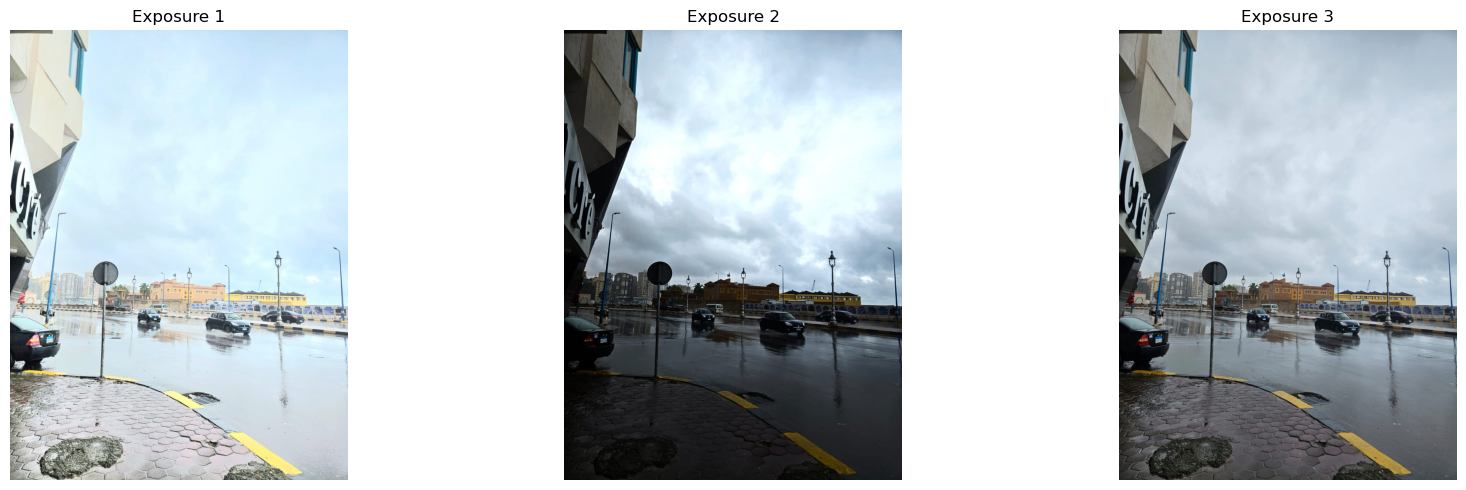

In [ ]:
# Load exposure bracket images — CHANGE THESE FILENAMES
files = ['bright.jpeg', 'dark.jpeg', 'normal.jpeg']  
images = [load_image(f'../images/task8/{f}') for f in files]

print(f"Loaded {len(images)} exposures")
show_images_row(images, [f"Exposure {i+1}" for i in range(len(images))],
                figsize=(6*len(images), 5))

## 2. Align Images

In [5]:
images = align_images(images)
print("Images aligned!")

Images aligned!


## 3. Method 1 — Mertens Exposure Fusion (No exposure times needed)

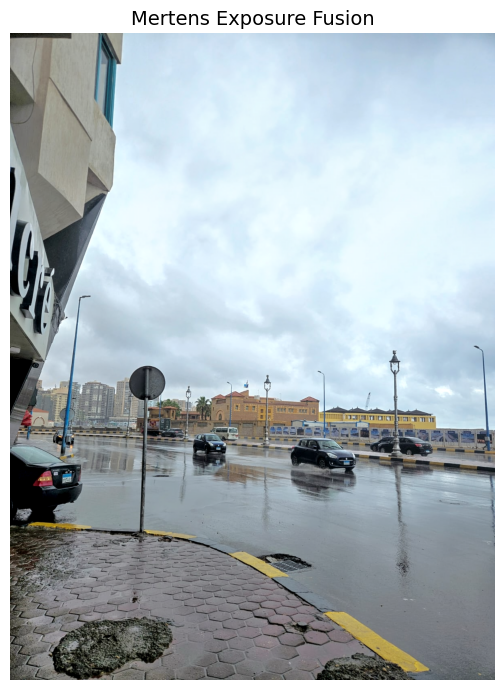

In [6]:
fusion = mertens_fusion(images)
show_image(fusion, "Mertens Exposure Fusion", figsize=(10, 7))

## 4. Method 2 — Debevec HDR + Tone Mapping

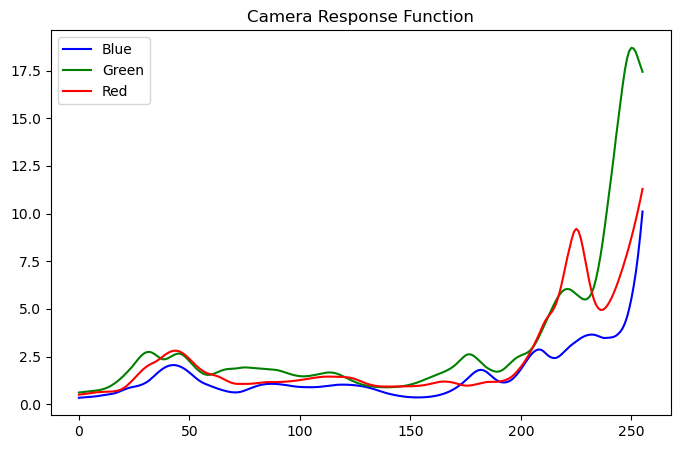

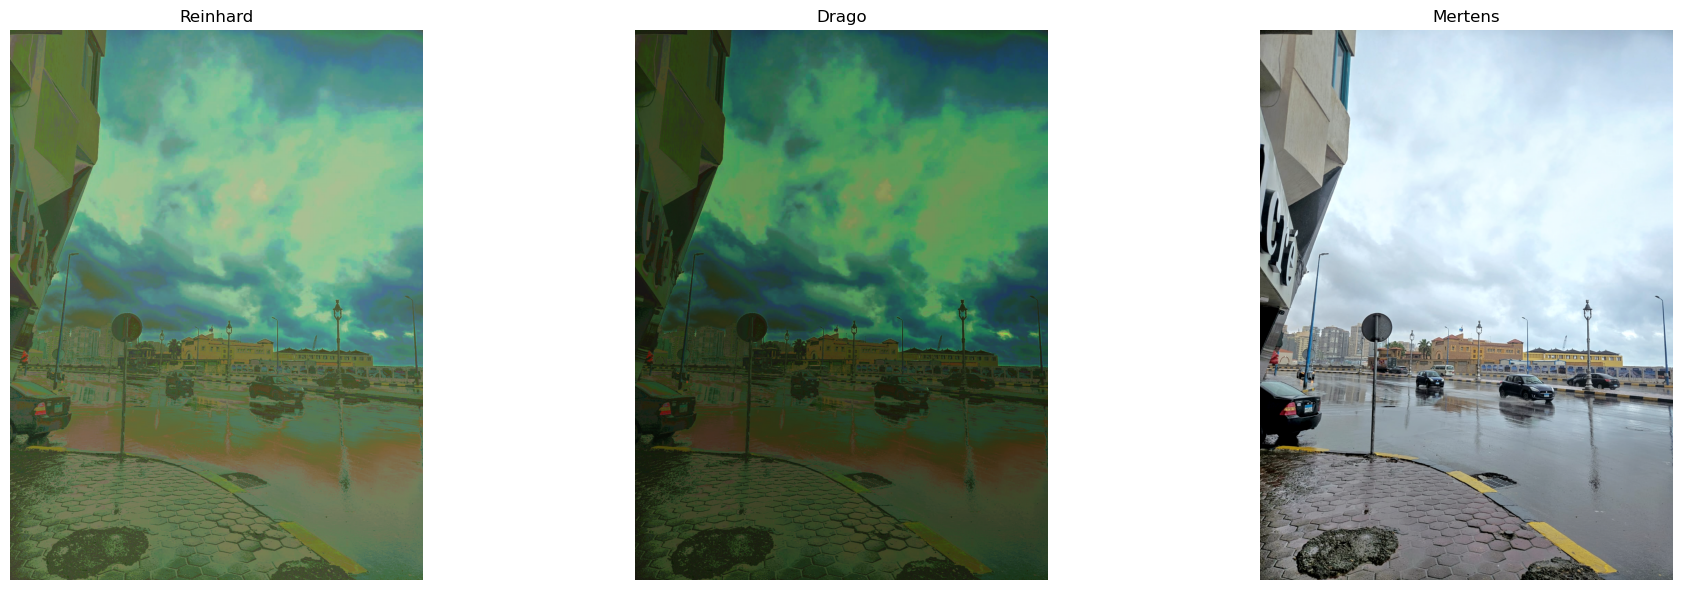

In [7]:
# Exposure times (adjust to match your actual camera settings)
exposure_times = np.array([1/30, 1/60, 1/125], dtype=np.float32)  # <-- ADJUST

try:
    response = estimate_response_curve(images, exposure_times)
    hdr = merge_to_hdr(images, exposure_times, response)

    # Plot camera response function
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(response[:, :, 0], 'b', label='Blue')
    ax.plot(response[:, :, 1], 'g', label='Green')
    ax.plot(response[:, :, 2], 'r', label='Red')
    ax.set_title("Camera Response Function")
    ax.legend()
    plt.show()

    # Tone mapping
    ldr_reinhard = tonemap_reinhard(hdr)
    ldr_drago = tonemap_drago(hdr)

    show_images_row([ldr_reinhard, ldr_drago, fusion],
                   ["Reinhard", "Drago", "Mertens"],
                   figsize=(20, 6))
except Exception as e:
    print(f"Debevec failed: {e}")
    print("Use Mertens fusion result instead.")

## 5. Final Comparison

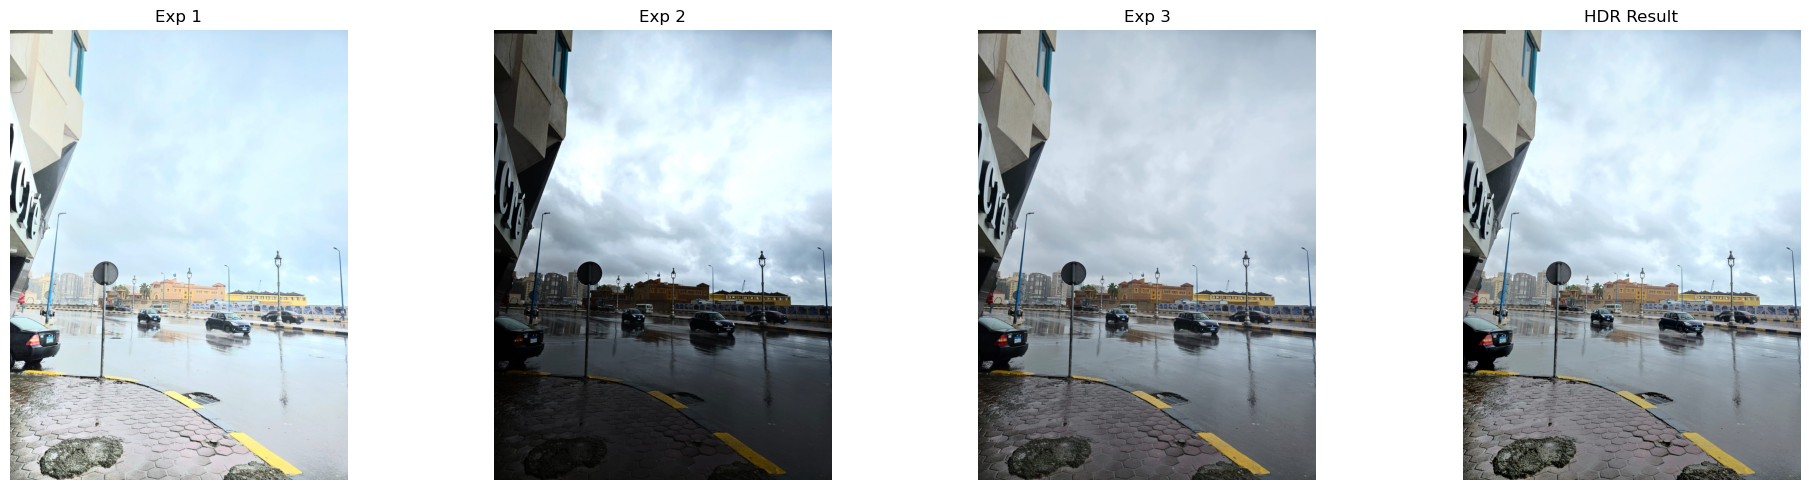

In [8]:
show_images_row(
    images + [fusion],
    [f"Exp {i+1}" for i in range(len(images))] + ["HDR Result"],
    figsize=(5*len(images)+5, 5)
)

## 6. Save Results

In [9]:
os.makedirs('../outputs/task8', exist_ok=True)
cv2.imwrite('../outputs/task8/hdr_mertens.png', fusion)
try:
    cv2.imwrite('../outputs/task8/hdr_reinhard.png', ldr_reinhard)
    cv2.imwrite('../outputs/task8/hdr_drago.png', ldr_drago)
except:
    pass
print("Saved to outputs/task8/")

Saved to outputs/task8/
